# Benchmark: AutoCarver vs. optbinning vs. KBinsDiscretizer

This notebook runs the three binning libraries side-by-side on two public datasets:

1. **German Credit** — binary classification, mixed numeric / categorical features, 1,000 rows.
2. **California Housing** — regression, all-numeric features, 20,640 rows.

For each library and dataset, we report:

- **`fit` and `transform` wall-clock** (seconds)
- **Downstream-model score** — AUC for binary, R² for regression — using a linear model (logistic regression / ridge) on the one-hot-encoded bin output
- **`train` → `test` score drop** as a coarse proxy for drift sensitivity

All three libraries see the same `train + dev` data and are evaluated on the same held-out `test`. AutoCarver uses the dev sample for its built-in robustness veto; optbinning and KBinsDiscretizer don't have a dev-set concept and so treat the union of train + dev as one pooled training set — which is the comparison practitioners actually run.

**This is not an IV / Tschuprow's T leaderboard.** Those metrics structurally favour the library whose objective they are. The downstream-model score is the metric a real scorecard team would use to pick a binner.

Numbers come from a single run on a single machine with a fixed seed; treat them as illustrative, not as authoritative benchmark figures. Re-run on your own data before drawing conclusions.

## Setup

In [1]:
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing, fetch_openml
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import r2_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import KBinsDiscretizer

from AutoCarver import BinaryCarver, ContinuousCarver, Features
from AutoCarver.discretizers.utils.base_discretizer import ProcessingConfig

try:
    from optbinning import ContinuousOptimalBinning, OptimalBinning

    HAS_OPTBINNING = True
except ImportError:
    HAS_OPTBINNING = False
    print('optbinning is not installed \u2014 its rows will be skipped.')

SEED = 42
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 3.5)

In [2]:
def one_hot(df):
    """Treat every bin label as a categorical level and one-hot encode it.

    Lets a linear downstream model consume any of the three libraries' outputs
    uniformly, without us computing WoE per bin.
    """
    return pd.get_dummies(df.astype(str), drop_first=True).astype(float)


def fit_eval_binary(X_train, X_test, y_train, y_test):
    Xtr = one_hot(X_train)
    Xte = one_hot(X_test).reindex(columns=Xtr.columns, fill_value=0.0)
    model = LogisticRegression(max_iter=1000, random_state=SEED).fit(Xtr, y_train)
    return {
        'train_auc': roc_auc_score(y_train, model.predict_proba(Xtr)[:, 1]),
        'test_auc': roc_auc_score(y_test, model.predict_proba(Xte)[:, 1]),
    }


def fit_eval_regression(X_train, X_test, y_train, y_test):
    Xtr = one_hot(X_train)
    Xte = one_hot(X_test).reindex(columns=Xtr.columns, fill_value=0.0)
    model = Ridge(random_state=SEED).fit(Xtr, y_train)
    return {
        'train_r2': r2_score(y_train, model.predict(Xtr)),
        'test_r2': r2_score(y_test, model.predict(Xte)),
    }


def plot_bars(results_df, score_cols, title):
    fig, axes = plt.subplots(1, len(score_cols), figsize=(4 * len(score_cols), 3.5))
    if len(score_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, score_cols):
        results_df.plot.bar(x='library', y=col, ax=ax, legend=False, color='#4C72B0')
        ax.set_title(col)
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=0)
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

In [3]:
from AutoCarver.combinations.binary import CramervCombinations

MAX_N_MOD = 5
MIN_FREQ = 0.05

def bin_with_autocarver(X_train, y_train, X_dev, y_dev, X_test, categoricals, quantitatives, kind):
    Carver = BinaryCarver if kind == 'binary' else ContinuousCarver
    features = Features(categoricals=categoricals, numericals=quantitatives)
    config = ProcessingConfig(verbose=True)  # showing statistics
    combination_evaluator = CramervCombinations() if kind == 'binary' else None
    carver = Carver(features=features, min_freq=MIN_FREQ, max_n_mod=MAX_N_MOD, config=config,combination_evaluator=combination_evaluator)

    t0 = time.perf_counter()
    X_tr = carver.fit_transform(X_train.copy(), y_train, X_dev=X_dev.copy(), y_dev=y_dev)
    fit_t = time.perf_counter() - t0

    X_dv = carver.transform(X_dev.copy())
    t1 = time.perf_counter()
    X_te = carver.transform(X_test.copy())
    transform_t = time.perf_counter() - t1
    return pd.concat([X_tr, X_dv]), X_te, fit_t, transform_t, carver


def bin_with_optbinning(X_train, y_train, X_dev, y_dev, X_test, categoricals, quantitatives, kind):
    Cls = OptimalBinning if kind == 'binary' else ContinuousOptimalBinning
    X_all = pd.concat([X_train, X_dev])
    y_all = pd.concat([y_train, y_dev])
    binners = {}
    train_binned = pd.DataFrame(index=X_all.index)
    test_binned = pd.DataFrame(index=X_test.index)

    t0 = time.perf_counter()
    for col in X_all.columns:
        dtype = 'categorical' if col in categoricals else 'numerical'
        binner = Cls(name=col, dtype=dtype, min_prebin_size=MIN_FREQ/2, max_n_bins=MAX_N_MOD)
        binner.fit(X_all[col].to_numpy(), y_all.to_numpy())
        binners[col] = binner
        train_binned[col] = binner.transform(X_all[col].to_numpy(), metric='bins')
    fit_t = time.perf_counter() - t0

    t1 = time.perf_counter()
    for col, b in binners.items():
        test_binned[col] = b.transform(X_test[col].to_numpy(), metric='bins')
    transform_t = time.perf_counter() - t1
    return train_binned, test_binned, fit_t, transform_t, binners


def bin_with_kbins(X_train, X_dev, X_test, categoricals, quantitatives, n_bins=5):
    X_all = pd.concat([X_train, X_dev])
    num_train = X_all[quantitatives].apply(lambda c: c.fillna(c.median()))
    num_test = X_test[quantitatives].apply(lambda c: c.fillna(c.median()))
    kbd = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='quantile')

    t0 = time.perf_counter()
    binned_num_train = pd.DataFrame(
        kbd.fit_transform(num_train), columns=quantitatives, index=X_all.index
    )
    fit_t = time.perf_counter() - t0

    t1 = time.perf_counter()
    binned_num_test = pd.DataFrame(
        kbd.transform(num_test), columns=quantitatives, index=X_test.index
    )
    transform_t = time.perf_counter() - t1

    # KBins has no opinion on categoricals — pass them through as labels
    train = pd.concat([binned_num_train, X_all[categoricals].astype(str)], axis=1)
    test = pd.concat([binned_num_test, X_test[categoricals].astype(str)], axis=1)
    return train, test, fit_t, transform_t, kbd

## Binary classification — German Credit

20 features (numeric + categorical), 1,000 rows, target = `class == 'bad'`. Train / dev / test split = 60 / 20 / 20 %.

In [4]:
credit = fetch_openml(data_id=31, as_frame=True)
df = credit.frame.copy()

y_binary = (df['class'] == 'bad').astype(int)
X_binary = df.drop(columns=['class'])

X_train, X_rest, y_train, y_rest = train_test_split(
    X_binary, y_binary, test_size=0.4, random_state=SEED, stratify=y_binary,
)
X_dev, X_test, y_dev, y_test = train_test_split(
    X_rest, y_rest, test_size=0.5, random_state=SEED, stratify=y_rest,
)

categoricals = [c for c in X_binary.columns if X_binary[c].dtype == object or isinstance(X_binary[c].dtype, pd.CategoricalDtype)]
quantitatives = [c for c in X_binary.columns if c not in categoricals]

print(f'train={len(X_train)}, dev={len(X_dev)}, test={len(X_test)}')
print(f'categoricals={len(categoricals)}, numericals={len(quantitatives)}')
print(f'bad rate (train)={y_train.mean():.3f}, (test)={y_test.mean():.3f}')

train=600, dev=200, test=200
categoricals=13, numericals=7
bad rate (train)=0.300, (test)=0.300


In [5]:
y_train_full = pd.concat([y_train, y_dev])

runs = [(
    'AutoCarver',
    lambda: bin_with_autocarver(X_train, y_train, X_dev, y_dev, X_test, categoricals, quantitatives, 'binary'),
)]
if HAS_OPTBINNING:
    runs.append((
        'optbinning',
        lambda: bin_with_optbinning(X_train, y_train, X_dev, y_dev, X_test, categoricals, quantitatives, 'binary'),
    ))
runs.append((
    'KBinsDiscretizer',
    lambda: bin_with_kbins(X_train, X_dev, X_test, categoricals, quantitatives),
))

rows = []
for name, run in runs:
    X_tr, X_te, fit_t, transform_t, carver = run()
    scores = fit_eval_binary(X_tr, X_te, y_train_full, y_test)
    rows.append({
        'library': name,
        'fit_s': round(fit_t, 3),
        'transform_s': round(transform_t, 4),
        'train_auc': round(scores['train_auc'], 4),
        'test_auc': round(scores['test_auc'], 4),
        'auc_drop': round(scores['train_auc'] - scores['test_auc'], 4),
    })

binary_results = pd.DataFrame(rows)
binary_results

------
--- [QuantitativeDiscretizer] Fit Features(['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents'])
 - [ContinuousDiscretizer] Fit Features(['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents'])
 - [OrdinalDiscretizer] Fit Features(['duration', 'installment_commitment', 'residence_since', 'existing_credits', 'num_dependents'])
------

------
--- [QualitativeDiscretizer] Fit Features(['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker'])
 - [CategoricalDiscretizer] Fit Features(['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker'])
----

X distribution 
 
 
   
 target_mean 
 frequency 
 count 
 
 
 
 
 no checking 
 0.1317 
 0.4050 
 243 
 
 
 >=200 
 0.2778 
 0.0600 
 36 
 
 
 0<=X<200 
 0.3896 
 0.2567 
 154 
 
 
 <0 
 0.4671 
 0.2783 
 167 
 
 
 
 
 
 X_dev distribution 
 
 
 target_mean 
 frequency 
 count 
 
 
 
 
 0.0694 
 0.3600 
 72 
 
 
 0.0833 
 0.0600 
 12 
 
 
 0.3710 
 0.3100 
 62 
 
 
 0.5741 
 0.2700 
 54

 [BinaryCarver] Carved distribution


X distribution 
 
 
   
 target_mean 
 frequency 
 count 
 
 
 
 
 no checking 
 0.1317 
 0.4050 
 243 
 
 
 >=200 
 0.2778 
 0.0600 
 36 
 
 
 0<=X<200 
 0.3896 
 0.2567 
 154 
 
 
 <0 
 0.4671 
 0.2783 
 167 
 
 
 
 
 
 X_dev distribution 
 
 
 target_mean 
 frequency 
 count 
 
 
 
 
 0.0694 
 0.3600 
 72 
 
 
 0.0833 
 0.0600 
 12 
 
 
 0.3710 
 0.3100 
 62 
 
 
 0.5741 
 0.2700 
 54

--- [BinaryCarver] Fit Categorical('credit_history') (2/20)
 [BinaryCarver] Raw distribution


...

--- [BinaryCarver] Fit Numerical('existing_credits') (19/20)
 [BinaryCarver] Raw distribution


X distribution 
 
 
   
 target_mean 
 frequency 
 count 
 
 
 
 
 (-inf, 1.00e+00] 
 0.3061 
 0.6317 
 379 
 
 
 (1.00e+00, 2.00e+00] 
 0.2899 
 0.3450 
 207 
 
 
 (2.00e+00, inf) 
 0.2857 
 0.0233 
 14 
 
 
 
 
 
 X_dev distribution 
 
 
 target_mean 
 frequency 
 count 
 
 
 
 
 0.3000 
 0.6500 
 130 
 
 
 0.3016 
 0.3150 
 63 
 
 
 0.2857 
 0.0350 
 7

--- [BinaryCarver] Fit Numerical('num_dependents') (20/20)
 [BinaryCarver] Raw distribution


X distribution 
 
 
   
 target_mean 
 frequency 
 count 
 
 
 
 
 (-inf, 1.0e+00] 
 0.2984 
 0.8433 
 506 
 
 
 (1.0e+00, inf) 
 0.3085 
 0.1567 
 94 
 
 
 
 
 
 X_dev distribution 
 
 
 target_mean 
 frequency 
 count 
 
 
 
 
 0.3000 
 0.8500 
 170 
 
 
 0.3000 
 0.1500 
 30

,library,fit_s,transform_s,train_auc,test_auc,auc_drop
0,AutoCarver,2.690,0.0139,0.8496,0.8044,0.0451
1,optbinning,1.216,0.0145,0.8523,0.7931,0.0592
2,KBinsDiscretizer,0.003,0.0009,0.8401,0.7943,0.0458


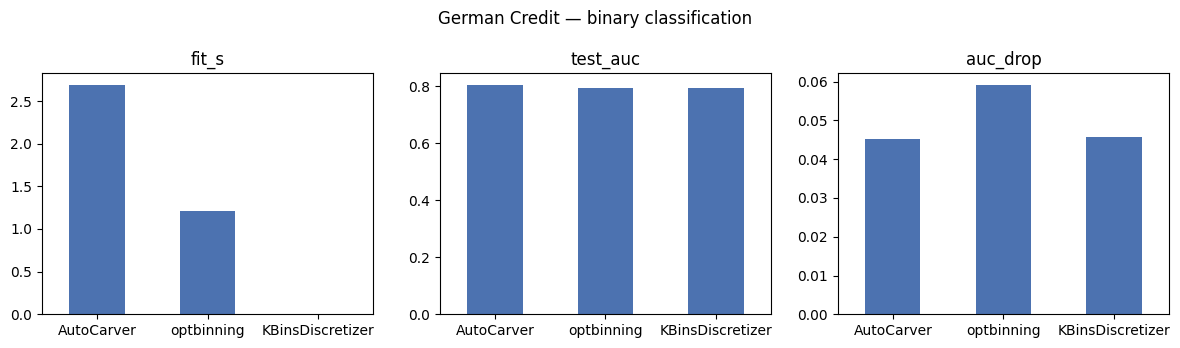

In [6]:
plot_bars(binary_results, ['fit_s', 'test_auc', 'auc_drop'], 'German Credit \u2014 binary classification')

## Regression — California Housing

6 numeric demographic features (Latitude / Longitude dropped — see comment in the next cell), 20,640 rows, target = median house value. Same 60 / 20 / 20 split.

In [7]:
housing = fetch_california_housing(as_frame=True)
X_reg = housing.frame.drop(columns=['MedHouseVal'])
y_reg = housing.frame['MedHouseVal']

X_train, X_rest, y_train, y_rest = train_test_split(X_reg, y_reg, test_size=0.4, random_state=SEED)
X_dev, X_test, y_dev, y_test = train_test_split(X_rest, y_rest, test_size=0.5, random_state=SEED)

quantitatives = list(X_reg.columns)
categoricals = []

print(f'train={len(X_train)}, dev={len(X_dev)}, test={len(X_test)}')
print(f'numericals={len(quantitatives)} ({quantitatives})')

train=12384, dev=4128, test=4128
numericals=8 (['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude'])


In [8]:
y_train_full = pd.concat([y_train, y_dev])

runs = [(
    'AutoCarver',
    lambda: bin_with_autocarver(X_train, y_train, X_dev, y_dev, X_test, categoricals, quantitatives, 'continuous'),
)]
if HAS_OPTBINNING:
    runs.append((
        'optbinning',
        lambda: bin_with_optbinning(X_train, y_train, X_dev, y_dev, X_test, categoricals, quantitatives, 'continuous'),
    ))
runs.append((
    'KBinsDiscretizer',
    lambda: bin_with_kbins(X_train, X_dev, X_test, categoricals, quantitatives),
))

rows = []
for name, run in runs:
    X_tr, X_te, fit_t, transform_t, carver = run()
    scores = fit_eval_regression(X_tr, X_te, y_train_full, y_test)
    rows.append({
        'library': name,
        'fit_s': round(fit_t, 3),
        'transform_s': round(transform_t, 4),
        'train_r2': round(scores['train_r2'], 4),
        'test_r2': round(scores['test_r2'], 4),
        'r2_drop': round(scores['train_r2'] - scores['test_r2'], 4),
    })

regression_results = pd.DataFrame(rows)
regression_results

------
--- [QuantitativeDiscretizer] Fit Features(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude'])
 - [ContinuousDiscretizer] Fit Features(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude'])
 - [OrdinalDiscretizer] Fit Features(['HouseAge', 'Latitude', 'Longitude'])
------

---------
------ [ContinuousCarver] Fit Features(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude'])
--- [ContinuousCarver] Fit Numerical('MedInc') (1/8)
 [ContinuousCarver] Raw distribution


,target_mean,frequency,count
"(-inf, 1.335e+00]",1.1984,0.0250,310
"(1.335e+00, 1.593e+00]",1.0105,0.0250,310
"(1.593e+00, 1.740e+00]",1.1133,0.0250,309
"(1.740e+00, 1.906e+00]",1.1535,0.0252,312
"(1.906e+00, 2.029e+00]",1.2090,0.0248,307
"(2.029e+00, 2.152e+00]",1.2141,0.0251,311
"(2.152e+00, 2.243e+00]",1.2417,0.0250,310
"(2.243e+00, 2.350e+00]",1.3827,0.0249,308
"(2.350e+00, 2.468e+00]",1.3614,0.0250,310
"(2.468e+00, 2.569e+00]",1.4190,0.0250,309


 [ContinuousCarver] Carved distribution


X distribution 
 
 
   
 target_mean 
 frequency 
 count 
 
 
 
 
 (-inf, 2.47e+00] 
 1.2093 
 0.2250 
 2787 
 
 
 (2.47e+00, 3.13e+00] 
 1.5796 
 0.1750 
 2167 
 
 
 (3.13e+00, 4.07e+00] 
 1.9560 
 0.2251 
 2788 
 
 
 (4.07e+00, 5.83e+00] 
 2.4238 
 0.2499 
 3095 
 
 
 (5.83e+00, inf) 
 3.7524 
 0.1249 
 1547 
 
 
 
 
 
 X_dev distribution 
 
 
 target_mean 
 frequency 
 count 
 
 
 
 
 1.2323 
 0.2275 
 939 
 
 
 1.5934 
 0.1747 
 721 
 
 
 1.9604 
 0.2425 
 1001 
 
 
 2.4652 
 0.2372 
 979 
 
 
 3.6870 
 0.1182 
 488

--- [ContinuousCarver] Fit Numerical('HouseAge') (2/8)
 [ContinuousCarver] Raw distribution


...

--- [ContinuousCarver] Fit Numerical('Longitude') (8/8)
 [ContinuousCarver] Raw distribution


,target_mean,frequency,count
"(-inf, -1.2269e+02]",1.4063,0.0259,321
"(-1.2269e+02, -1.2247e+02]",2.8878,0.0259,321
"(-1.2247e+02, -1.2241e+02]",3.2397,0.0245,303
"(-1.2241e+02, -1.2229e+02]",2.1582,0.0262,324
"(-1.2229e+02, -1.2215e+02]",2.3071,0.0476,589
"(-1.2215e+02, -1.2206e+02]",2.5665,0.0263,326
"(-1.2206e+02, -1.2199e+02]",2.6265,0.0253,313
"(-1.2199e+02, -1.2191e+02]",2.6924,0.0237,294
"(-1.2191e+02, -1.2181e+02]",2.2919,0.0255,316
"(-1.2181e+02, -1.2157e+02]",1.7103,0.0242,300


 [ContinuousCarver] Carved distribution


X distribution 
 
 
   
 target_mean 
 frequency 
 count 
 
 
 
 
 (-inf, -1.218e+02] 
 2.4438 
 0.2509 
 3107 
 
 
 (-1.218e+02, -1.190e+02] 
 1.3787 
 0.2242 
 2776 
 
 
 (-1.190e+02, -1.183e+02] 
 3.0175 
 0.1029 
 1274 
 
 
 (-1.183e+02, -1.177e+02] 
 2.1601 
 0.2735 
 3387 
 
 
 (-1.177e+02, inf) 
 1.6155 
 0.1486 
 1840 
 
 
 
 
 
 X_dev distribution 
 
 
 target_mean 
 frequency 
 count 
 
 
 
 
 2.4780 
 0.2357 
 973 
 
 
 1.3487 
 0.2243 
 926 
 
 
 3.0414 
 0.0988 
 408 
 
 
 2.1328 
 0.2800 
 1156 
 
 
 1.6763 
 0.1611 
 665

,library,fit_s,transform_s,train_r2,test_r2,r2_drop
0,AutoCarver,5.890,0.0889,0.6652,0.6595,0.0057
1,optbinning,2.876,0.0083,0.5145,0.5077,0.0068
2,KBinsDiscretizer,0.009,0.0018,0.6181,0.6192,-0.0011


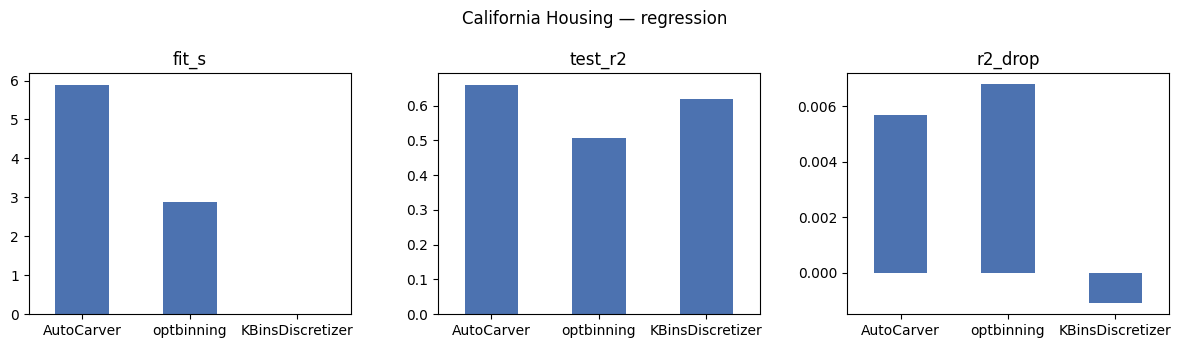

In [9]:
plot_bars(regression_results, ['fit_s', 'test_r2', 'r2_drop'], 'California Housing \u2014 regression')

## How to read these numbers

- **`fit_s` / `transform_s`** measure only `.fit` / `.transform` wall-clock — not data loading, not one-hot encoding, not the downstream model.
- **`test_auc` / `test_r2`** are the headline metric. They reflect how well a *simple* downstream model performs on each library's binned output. A tree-based downstream model would tell a different (and less binning-sensitive) story.
- **`auc_drop` / `r2_drop`** are `train - test` and measure how much each library's bins overfit. Lower is more robust. AutoCarver's dev-set veto is designed to keep this small.
- **Same data, same seed, same downstream model** across libraries — but a single run, on one machine, with one set of hyper-parameters. Treat as illustrative.

## When the result will move

- **Bigger `max_n_mod` / smaller `min_freq`** will improve AutoCarver and optbinning's in-sample scores at the cost of `*_drop`. KBins doesn't have a target, so it's mostly insensitive.
- **Different downstream model.** Gradient-boosted trees on the raw features beat any binning + linear pipeline. The point of binning is interpretability, not raw accuracy.
- **Different dataset.** German Credit is small; on a 10M-row credit-risk dataset, `fit_s` is what dominates the comparison.

See [comparison.rst](../../comparison.html) for the qualitative scope and algorithmic comparison.